## Agentes de IA para analise de dados - parte 2
usando `create_pandas_dataframe_agent`

## 1-librarys

In [1]:
import os
from dotenv import load_dotenv
import datetime
import time
import requests
import pandas as pd
from langchain.tools import tool
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

from langchain_experimental.agents import create_pandas_dataframe_agent

import matplotlib.pyplot as plt
import seaborn as sns

import sys
from io import StringIO


from langchain_core.globals import set_debug




# # Modelos LLM (Large Language Models)
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_groq import ChatGroq

print('#',time.strftime("%d/%m/%Y - %H:%M:%S"))

/tmp/ipykernel_18228/3030909707.py:11: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.agents import create_pandas_dataframe_agent


# 21/08/2026 - 17:30:53


## 2-load envs

In [2]:
# 2. Carregamento das variáveis de ambiente (.env)
ENV_PATH: str = '/home/akel/PycharmProjects/InsurMinds2026/.env'

def carrega_variaveis_ambiente() -> None:
    if os.path.exists(ENV_PATH):
        load_dotenv(ENV_PATH, override=True)
        print("✔ Variáveis de ambiente carregadas do arquivo .env")
    else:
        print(f"⚠ Aviso: Arquivo {ENV_PATH} não foi encontrado no diretório atual.")

carrega_variaveis_ambiente()

llm_gemini = ChatGoogleGenerativeAI(temperature=0, model="gemini-3.1-flash-lite-preview",google_api_key=os.getenv("GOOGLE_API"))
llm_llama = ChatGroq(temperature=0,model="openai/gpt-oss-20b",api_key=os.getenv("GROQ_API"))

set_debug(False)
print('#',time.strftime("%d/%m/%Y - %H:%M:%S"))

✔ Variáveis de ambiente carregadas do arquivo .env
# 21/08/2026 - 17:30:53


In [3]:
# from groq import Groq

# client = Groq(
#     api_key=os.getenv("GROQ_API")
# )

# modelos = client.models.list()

# for modelo in modelos.data:
#     print(modelo.id)

## 3-dataset

In [4]:
# Dados extraídos da tabela
wiki_dados = {
    'Capital': [
        'Vitória', 'Florianópolis', 'Curitiba', 'São Luís', 'Palmas',
        'Brasília', 'Goiânia', 'Belo Horizonte', 'Cuiabá', 'São Paulo',
        'Campo Grande', 'Rio de Janeiro', 'Aracaju', 'Boa Vista', 'Teresina',
        'Porto Alegre', 'Recife', 'Fortaleza', 'Natal', 'João Pessoa',
        'Salvador', 'Belém', 'Macapá', 'Rio Branco', 'Manaus',
        'Porto Velho', 'Maceió'
    ],
    'idh2000': [
        0.700, 0.660, 0.655, 0.582, 0.508,
        0.582, 0.591, 0.617, 0.577, 0.614,
        0.548, 0.607, 0.519, 0.546, 0.488,
        0.612, 0.538, 0.534, 0.547, 0.523,
        0.525, 0.504, 0.478, 0.423, 0.443,
        0.469, 0.433
    ],
    'idh2010': [
        0.805, 0.800, 0.768, 0.752, 0.749,
        0.742, 0.739, 0.737, 0.726, 0.725,
        0.724, 0.719, 0.708, 0.708, 0.707,
        0.702, 0.698, 0.695, 0.694, 0.693,
        0.679, 0.673, 0.663, 0.661, 0.658,
        0.638, 0.635
    ]
}

# # Criando o DataFrame
dados_cidade = pd.DataFrame(wiki_dados)
## dicinario do data_frame
bases={'dados_cidade':dados_cidade}
print('#',time.strftime("%d/%m/%Y - %H:%M:%S"))

# 21/08/2026 - 17:30:53


## 3. tools, defs e agent

In [5]:
# TOOL e FUNCTION
#--------------------------------------------------------------------------------------------------------
@tool
def listar_bases() -> str:
    """
    Retorna os nomes dos conjuntos de dados disponíveis para análise.
    Use esta ferramenta quando o usuário perguntar quais dados,
    bases ou DataFrames estão disponíveis.
    """

    return "\n".join(bases.keys())


@tool
def estrutura_dataframe(nome_dataframe: str) -> str:
    """
    Retorna informações sobre a estrutura de um DataFrame.

    Args:
        nome_dataframe: Nome do DataFrame. Use base.keys()
    """

    if nome_dataframe not in bases:
        return f"DataFrame '{nome_dataframe}' não encontrado."

    df = bases[nome_dataframe]

    return f"""
Número de linhas: {df.shape[0]}
Número de colunas: {df.shape[1]}

Colunas:
{df.dtypes.to_string()}
"""
@tool
def estatisticas_dataframe(nome_dataframe: str) -> str:
    """
    Retorna estatísticas descritivas de um DataFrame.

    Args:
        nome_dataframe: Nome do DataFrame. Use base.keys()
    """

    if nome_dataframe not in bases:
        return f"DataFrame '{nome_dataframe}' não encontrado."

    df = bases[nome_dataframe]

    return df.describe(include="all").to_string()


@tool
def analisar_coluna(nome_dataframe: str,
                    coluna: str, operacao: str) -> str:
    """
    Realiza uma operação estatística em uma coluna numérica.

    Args:
        coluna: Nome da coluna.
        operacao: Operação desejada. Pode ser:
                  soma, media, minimo, maximo ou mediana.
    """
    if nome_dataframe not in bases:
        return f"DataFrame '{nome_dataframe}' não encontrado."

    df = bases[nome_dataframe]

    if coluna not in df.columns:
        return f"A coluna '{coluna}' não existe."

    if not pd.api.types.is_numeric_dtype(df[coluna]):
        return f"A coluna '{coluna}' não é numérica."

    operacoes = {
        "soma": df[coluna].sum,
        "media": df[coluna].mean,
        "minimo": df[coluna].min,
        "maximo": df[coluna].max,
        "mediana": df[coluna].median
    }

    if operacao not in operacoes:
        return f"Operação '{operacao}' não disponível."

    resultado = operacoes[operacao]()

    return f"{operacao} de '{coluna}': {resultado}"

@tool
def agrupar_dataframe(nome_dataframe: str,
                      coluna_grupo: str,
                      coluna_valor: str,
                      operacao: str) -> str:
    """
    Agrupa o DataFrame por uma coluna e aplica uma operação
    sobre outra coluna.

    Args:
        coluna_grupo: Coluna utilizada para agrupamento.
        coluna_valor: Coluna numérica analisada.
        operacao: soma, media, minimo, maximo ou contagem.
    """
    
    if nome_dataframe not in bases:
        return f"DataFrame '{nome_dataframe}' não encontrado."
    df = bases[nome_dataframe]

    if coluna_grupo not in df.columns:
        return f"A coluna '{coluna_grupo}' não existe."

    if coluna_valor not in df.columns:
        return f"A coluna '{coluna_valor}' não existe."

    operacoes = {
        "soma": "sum",
        "media": "mean",
        "minimo": "min",
        "maximo": "max",
        "contagem": "count"
    }

    if operacao not in operacoes:
        return f"Operação '{operacao}' não disponível."

    resultado = (
        df.groupby(coluna_grupo)[coluna_valor]
        .agg(operacoes[operacao])
        .sort_values(ascending=False)
    )

    return resultado.to_string()

ferramentas_estatisticas = [
    listar_bases,
    estrutura_dataframe,
    estatisticas_dataframe,
    analisar_coluna,
    agrupar_dataframe
]  

def mostrar_ferramentas(resposta):
    """
    exibir ferramentas utilizadas pelo agente
    """
    
    print("\n--- Ferramentas utilizadas ---")

    contador = 0

    for mensagem in resposta["messages"]:

        # Ferramentas solicitadas pelo agente
        if hasattr(mensagem, "tool_calls") and mensagem.tool_calls:

            for chamada in mensagem.tool_calls:
                contador += 1

                print(f"\nFerramenta usada: {chamada['name']}")
                print(f"Entrada enviada: {chamada['args']}")

        # Resultado retornado pela ferramenta
        if mensagem.type == "tool":
            print(f"Resposta da ferramenta: {mensagem.content}")

    print(f"\nTotal de chamadas: {contador}")
    print("-----------------------------\n")  

# AGENTES
#--------------------------------------------------------------------------------------------------------

def agente_estat_zero():
    modelo = llm_gemini
    ferramentas = ferramentas_estatisticas 

    # Memória de curto prazo
    checkpointer = InMemorySaver()

    agente = create_agent(
        model=modelo,
        tools=ferramentas,
        checkpointer=checkpointer,
        system_prompt="""
        Você é um agente especializado em análise de dados.
    Sempre utilize as ferramentas quando a resposta depender dos dados.

    Regras:
    - Não invente resultados.
    - Identifique corretamente qual DataFrame foi mencionado pelo usuário.
    - Utilize exatamente o nome dos dados ao chamar as ferramentas.
    - Quando necessário, consulte a estrutura do DataFrame antes de realizar cálculos.
    - Responda usando o seguinte formato.
    dado x     
    dimensão  : n x n
    informação consultada:
    ...
    """
    )

    return agente

def agente_estat_2(modelo=llm_gemini):

      # Suprimir saída do pandas/agente

    #modelo = llm_gemini
    #modelo = llm_llama

    prompt = """
    Você é um agente especializado em análise de dados.
    Sempre utilize as ferramentas quando a resposta depender dos dados.

    Regras:
    - Não invente resultados.
    - Realize os cálculos usando o DataFrame disponível.
    - Não utilize print() no código Python.
    - Evite métodos que imprimem diretamente no console, como df.info().
    - Quando necessário, consulte a estrutura dos dados antes de calcular.
    - Responda em português.

    Formato da resposta:
    dado: dados_cidade
    dimensão: n x m
    informação consultada:
    ...
    """
  # new aproache using creat_pandas_dataframe
    agente = create_pandas_dataframe_agent(
        llm=modelo,
        df=dados_cidade,   #< aqui deve ser um df ou lista de df. Não um dicionario
        prefix=prompt,
        agent_type="tool-calling",
        verbose=False,
        allow_dangerous_code=True,
        return_intermediate_steps=True
    )

    return agente


# CAll ask
#--------------------------------------------------------------------------------------------------------  

def perguntar(agente, pergunta, config,verbose=False):
    resposta = agente.invoke(
        {
            "messages": [
                {"role": "user", "content": pergunta}
            ]
        },
        config=config
    )

    
    # 2. Imprima os passos intermediários para verificar
    if verbose:
        mostrar_ferramentas(resposta)

    return resposta["messages"][-1].content[0]['text']

    
def query(agente, pergunta):
    resposta = agente.invoke({
        "input": pergunta
    })

    #resposta['output'][0]['text']
    return resposta

print('#',time.strftime("%d/%m/%Y - %H:%M:%S"))

# 21/08/2026 - 17:30:53


### Exemplo 1

In [6]:

pergunta0="Quais dados estão disponiveis da base de dados?"

#gemini
start_g = time.perf_counter()
executor_gemini = agente_estat_2(llm_gemini)
resposta_0_gemini = query(executor_gemini,pergunta0)
end_g = time.perf_counter()

#llama
start_l = time.perf_counter()
executor_llama = agente_estat_2(llm_llama)
resposta_0_llama = query(executor_llama,pergunta0)
end_l = time.perf_counter()


print(resposta_0_gemini)
print('-' * 50) 
print(f"{end_g-start_g:.4f}s")

print('\n')

print(resposta_0_llama)
print('-' * 50) 
print(f"{end_l-start_l:.4f}s")


['Capital', 'idh2000', 'idh2010']
{'input': 'Quais dados estão disponiveis da base de dados?', 'output': [{'type': 'text', 'text': "dado: dados_cidade\ndimensão: 27 x 3\ninformação consultada:\nAs colunas disponíveis na base de dados são: 'Capital', 'idh2000' e 'idh2010'.", 'index': 0, 'extras': {'signature': 'EnEKbwERTTIPbMj+HZGAjdorWvawoeWI96Ak+kGUDqDj7iZwTZ6vSwEYAB3dLBz3hrWqeWR4UpBuPSLKa+YDaoPHfnCMT0Fgg9AFPq0I/RoCCcZ8M4HRERwjOzVPR+9czVyqUydmloI9jogv7Z1qeaoLaA=='}}], 'intermediate_steps': [(ToolAgentAction(tool='python_repl_ast', tool_input={'query': 'print(df.columns.tolist())\nprint(df.shape)\n'}, log="\nInvoking: `python_repl_ast` with `{'query': 'print(df.columns.tolist())\\nprint(df.shape)\\n'}`\n\n\n", message_log=[AIMessageChunk(content=[], additional_kwargs={'function_call': {'name': 'python_repl_ast', 'arguments': '{"query": "print(df.columns.tolist())\\nprint(df.shape)\\n"}'}, '__gemini_function_call_thought_signatures__': {'call_365631': 'EnEKbwERTTIPSe7wuCcTWQ/eGbnh7N9/wF

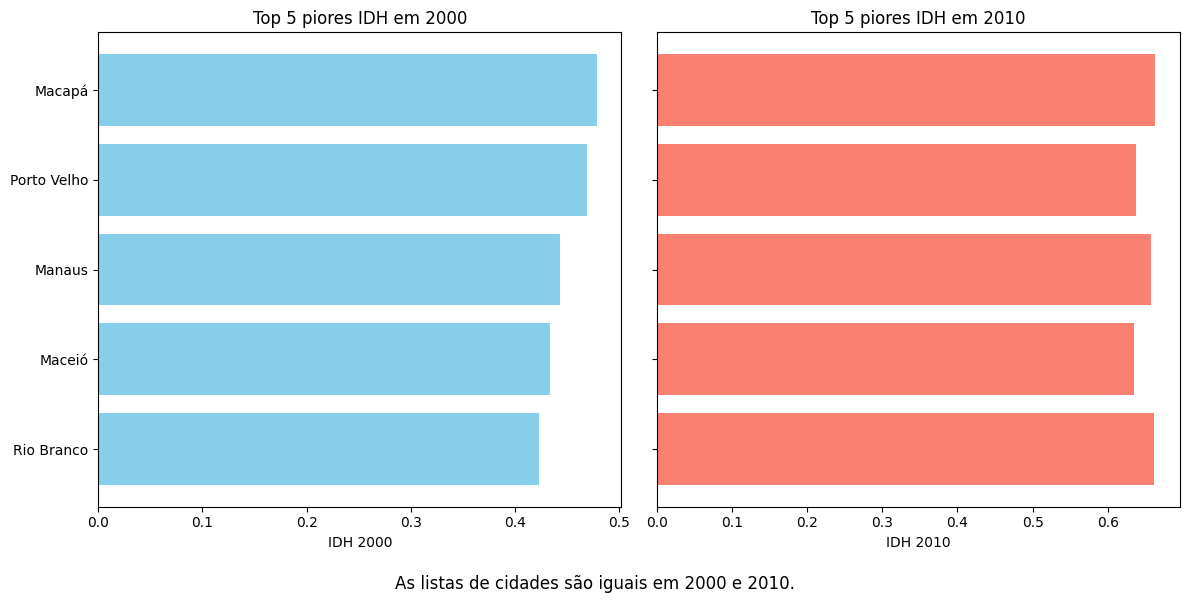

In [17]:
pergunta2="faça um subplot de barras horizontais com 2 graficos. grafico 1:Da esquerda top 5 piores IDH em 2000,grafico2:Da direita  top 5 piores IDH em 2010.Add um texto abaixo informando a diferença das cidades de 2000 e 2010 caso exista."

executor_llama = agente_estat_2(llm_llama)
R=query(executor_llama,pergunta2)

